In [41]:
import torch
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt 



In [42]:
image_path = '/Users/arhaan/Documents/Codes/Image processing/Screenshot 2025-12-31 at 12.53.46 AM.png'

In [43]:
def load_and_prep_image(image_path):
    
    raw_image = Image.open(image_path).convert("RGB") #loading raw image
    #one doubt i have is why are we converting here?: we are forcing every sort of image to be a channel image thats it.. utna hi smjha..

    tensor_image = transforms.ToTensor()(raw_image)
    #Also this transforms.ToTensor function also performs the transformation of HWC to CHW because pil libraries or openCV wale HWC use krti hai but pytorch me CHW mangta

    batched_tensor = tensor_image.unsqueeze(0)
    #makes a batch with single image.. multiple kaise kre?

    return raw_image, batched_tensor

In [44]:
original_pil,input_tensor = load_and_prep_image(image_path)

print(f"original size: {original_pil.size}")
print(f"Processed size: {input_tensor.shape}")

original size: (130, 210)
Processed size: torch.Size([1, 3, 210, 130])


In [45]:
inp_h = input_tensor.shape[2]
inp_w = input_tensor.shape[3]

otp_h = 1024
otp_w = 1024

ratio_h = (inp_h/otp_h)
ratio_w = (inp_w/otp_w)

In [46]:
new_image = torch.zeros((1,3,otp_h,otp_w))

In [47]:
def nearest_neighbour(input_tensor):
    for y_out in range(otp_h):
        for x_out in range(otp_w):
            src_add_x = int(x_out*ratio_w)
            src_add_y = int(y_out*ratio_h)

            new_image[:,:,y_out,x_out] = input_tensor[:,:,src_add_y,src_add_x]

    return new_image            

            

In [48]:
def visualize_result(tensor_image):
    # 1. Clean up the data
    # Clone it so we don't mess up the original calculation
    #image_to_show = tensor_image.clone().detach().cpu()
    
    # 2. Remove the batch dimension (The '1')
    # Shape: [1, 3, H, W] -> [3, H, W]
    image_to_show = tensor_image.squeeze(0)
    
    # 3. Swap dimensions for Matplotlib
    # Shape: [3, H, W] -> [H, W, 3] (Channels Last)
    image_to_show = image_to_show.permute(1, 2, 0)
    
    # 4. Render
    plt.figure(figsize=(10, 10))
    plt.imshow(image_to_show)
    plt.axis('off') # Hide the ugly axis numbers
    plt.title("Nearest Neighbor Result")
    plt.show()

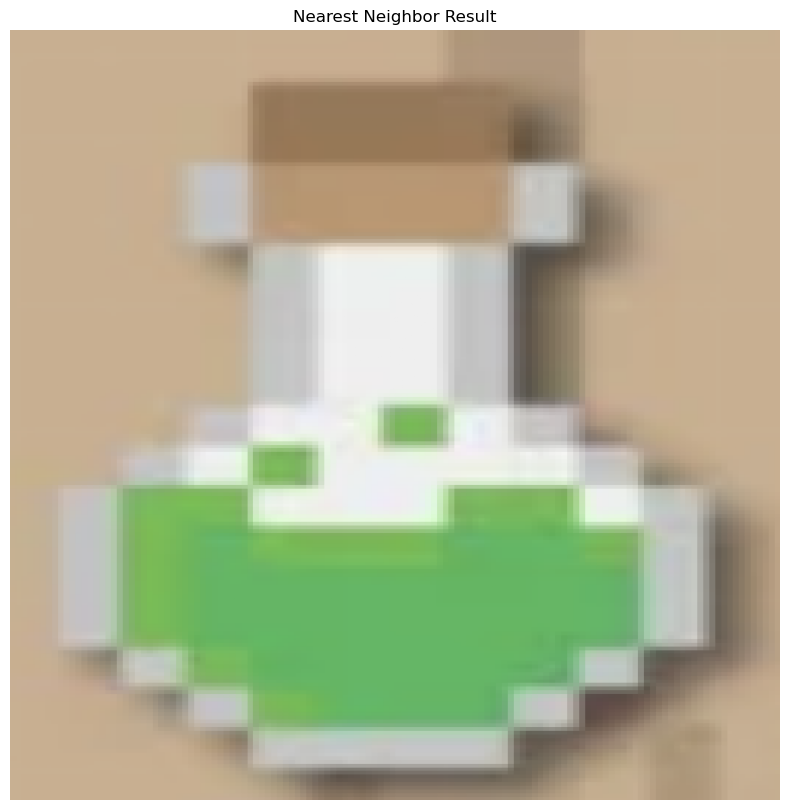

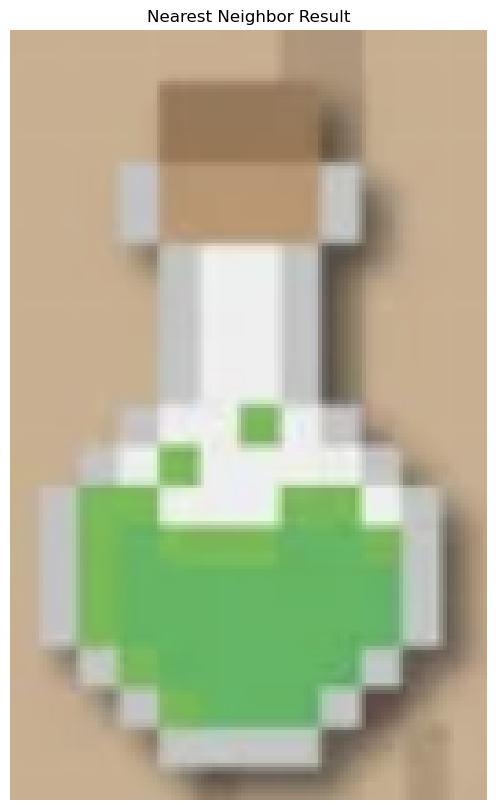

FInal shape : torch.Size([1, 3, 1024, 1024])


In [49]:
final_output = nearest_neighbour(input_tensor)
visualize_result(final_output)

visualize_result(input_tensor)

print(f"FInal shape : {final_output.shape}")